In [1]:
import os
# if you want to restrict to a particular GPU, use:
#os.environ["CUDA_VISIBLE_DEVICES"] = "0" # restricting to GPU 0
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"
# if needed in some systems, you may enable 64 bit precision for jax
# os.environ["JAX_ENABLE_X64"] = "True"


import jax.random as jr
import src.utils as utils
import jax.random as jr
import src.estimator_fullstack as est_online

from src.plotting_utils import plot_transition_graph

# First, we build our transition graph

Micro to meso map:
[0 2 3 3 2 1]


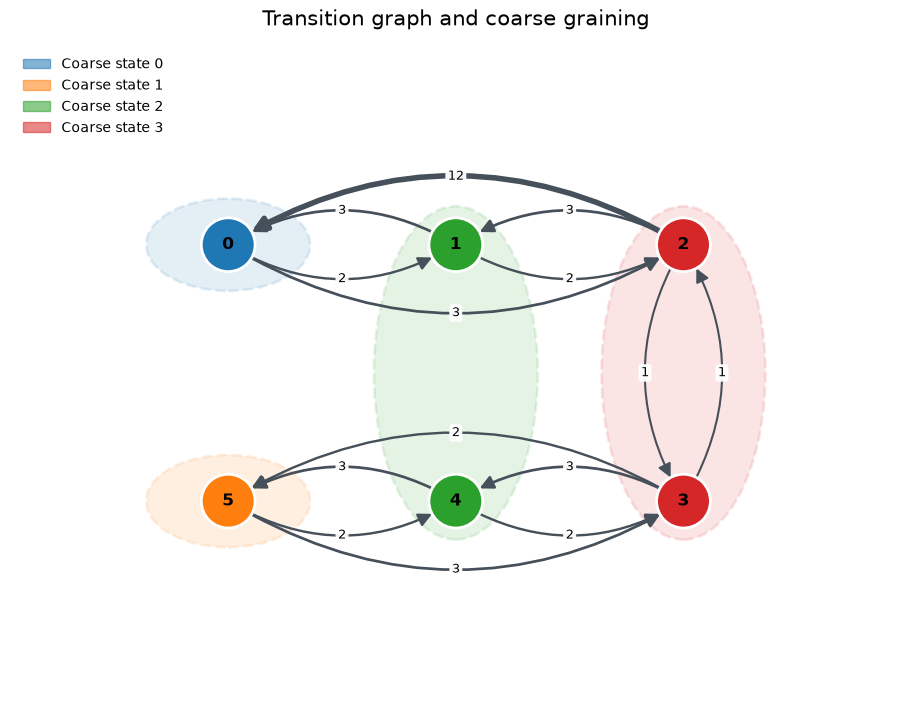

In [2]:
transition_list = []
omega = 2.0
kappa = 3.0
# first, we add the cycle 0->1->2->0. In cycle direction, we always have transition rate omega except for 2-> 0 which has rate 6 omega. Backwards, it is always kappa
transition_list.append((0, 1, omega))
transition_list.append((1, 2, omega))
transition_list.append((2, 0, 6 * omega))
transition_list.append((1, 0, kappa))
transition_list.append((2, 1, kappa))
transition_list.append((0, 2, kappa))

# second, we add the cycle 5->4->3->5. In direction of this cycle (i.e. 5->4, 4->3, 3->5) we have rate omega, and in counter direction kappa
transition_list.append((5, 4, omega))
transition_list.append((4, 3, omega))
transition_list.append((3, 5, omega))
transition_list.append((4, 5, kappa))
transition_list.append((3, 4, kappa))
transition_list.append((5, 3, kappa))

# third, we connec the cyles between nodes 2 and 3 with a transition of rate 1 in both directions.
transition_list.append((2, 3, 1.0))
transition_list.append((3, 2, 1.0))

lumps = [[0], [5], [1,4], [2,3]]
positions = {
    0: (0, 1),
    1: (2, 1),
    2: (4, 1),
    3: (4, -1),
    4: (2, -1),
    5: (0, -1),
}
plot_transition_graph(
    transition_list,
    lumps,
    "six-state-process.png",
    positions=positions,
    arc_curvature=0.3,
)

micro_to_meso_array = utils.lump_list_to_micro_to_meso_map(lumps)
print(f"Micro to meso map:\n{micro_to_meso_array}")
transition_prob_array = utils.transition_list_to_prob_array(transition_list)


# We now simulate and estimate (one run)

In [3]:


steps_warmup = 10**6
max_steps = steps_warmup + 10**6 # to maximise parallelism, we run after warm up 10**6, across N_paths_per_batch = 10**3 paths, so merging that gives us 10**9 microscopic transitions 
N_paths_per_batch = 10**3
N_batches = 1 # if your GPU runs out of memory during simulation, you can iteratively simulate by increasing N_batches, which allows you to decrease max_steps and N_paths_per_batch


estimators_dict = est_online.estimate_online(
    transition_prob_array,
    micro_to_meso_array,
    N_batches=N_batches,
    N_paths_per_batch=N_paths_per_batch,
    steps_warmup=steps_warmup,
    max_steps_per_path=max_steps,
    estimators_to_use=[1, 2, 3, 4, 5, 6, 7, 8],
    key=jr.PRNGKey(0),
    counting_chunk_size=1_000_000,
)

print(estimators_dict)

Simulating 1 batches of 1000 paths each.
Per path, we will simulate 2000000 steps, of which the first 1000000 steps are warmup steps.
Thus, we will record 1000000 steps per path, which will be used for the estimation of the EPR.
Thus, effective number of steps for the estimation: 1000000000. In base of 10, this is 10^9.00
Counting independently on cuda:0 with canonical-index lookup, count dtype int32, and chunk_size=1000000.
For order k=1, the number of unique k+1 tuples of meso states that are possible is 10.
For order k=2, the number of unique k+1 tuples of meso states that are possible is 26.
For order k=3, the number of unique k+1 tuples of meso states that are possible is 66.
For order k=4, the number of unique k+1 tuples of meso states that are possible is 170.
For order k=5, the number of unique k+1 tuples of meso states that are possible is 434.
For order k=6, the number of unique k+1 tuples of meso states that are possible is 1114.
For order k=7, the number of unique k+1 tuple

Note that the call above `est_online.estimate_online(...)` does both simulation and estimation in one go. It reports the time that the estimator for each order takes, which will be ultimatley influenced by your hardware, and the choice of your parameters above.

## The result

In [9]:
# now we print the ratios
micro_epr = estimators_dict['dS_0'] # k=0 is in this implementation just the microscopic EPR
# we print the header
print("Estimator,\tValue,\tRatio to micro EPR")
for key, value in estimators_dict.items():
    print(f"{key},\t\t{value:.3f},\t{value/micro_epr:.3f}")

Estimator,	Value,	Ratio to micro EPR
dS_0,		0.191,	1.000
dS_1,		0.114,	0.595
dS_2,		0.245,	1.280
dS_3,		0.180,	0.944
dS_4,		0.196,	1.025
dS_5,		0.190,	0.993
dS_6,		0.191,	1.002
dS_7,		0.191,	0.999
dS_8,		0.191,	1.000
